In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_root = Path().resolve().parent
data_dir = project_root / "data"

df_daily = pd.read_csv(data_dir / "daily_clean.csv", parse_dates=['calendarDate'])
df_act = pd.read_csv(data_dir / "activities_clean.csv", parse_dates=['date'])

print(f"daily: {df_daily.shape}")
print(f"activities: {df_act.shape}")

daily: (887, 30)
activities: (259, 32)


In [3]:
# Summary stats — workouts
print("=== WORKOUT SUMMARY ===")
print(f"Date range:              {df_act['date'].min().date()} to {df_act['date'].max().date()}")
print(f"Total workouts:          {len(df_act)}")
print(f"Avg workouts/month:      {len(df_act) / df_act['date'].dt.to_period('M').nunique():.1f}")
print(f"Avg duration:            {df_act['duration_minutes'].mean():.1f} min")
print(f"Median duration:         {df_act['duration_minutes'].median():.1f} min")
print(f"Avg HR during workout:   {df_act['avgHr'].mean():.1f} bpm")
print(f"Most common activity:    {df_act['activityType'].value_counts().index[0]} ({df_act['activityType'].value_counts().iloc[0]} sessions)")
print(f"Avg battery drain:       {df_act['differenceBodyBattery'].mean():.1f}")

=== WORKOUT SUMMARY ===
Date range:              2023-12-11 to 2026-05-19
Total workouts:          259
Avg workouts/month:      9.6
Avg duration:            54.3 min
Median duration:         49.2 min
Avg HR during workout:   107.7 bpm
Most common activity:    yoga (83 sessions)
Avg battery drain:       -6.5


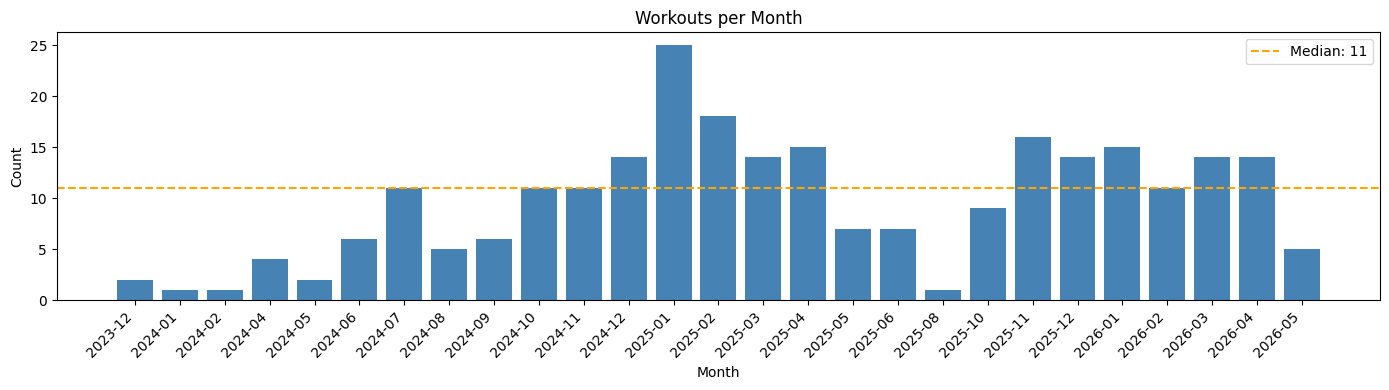

In [4]:
df_act['year_month'] = df_act['date'].dt.to_period('M')
workouts_per_month = df_act.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(workouts_per_month.index.astype(str), workouts_per_month.values, color='steelblue')
ax.axhline(workouts_per_month.median(), color='orange',
           linewidth=1.5, linestyle='--', label=f"Median: {workouts_per_month.median():.0f}")
ax.set_title('Workouts per Month')
ax.set_ylabel('Count')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

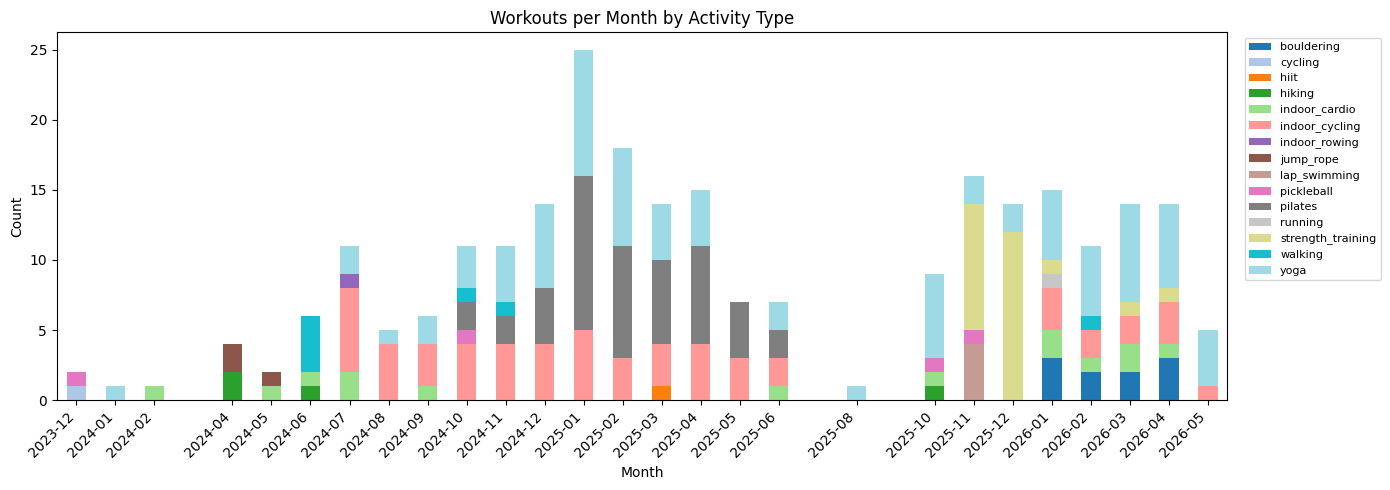

In [5]:
act_by_month = df_act.groupby(['year_month', 'activityType']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
act_by_month.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Workouts per Month by Activity Type')
ax.set_ylabel('Count')
ax.set_xlabel('Month')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

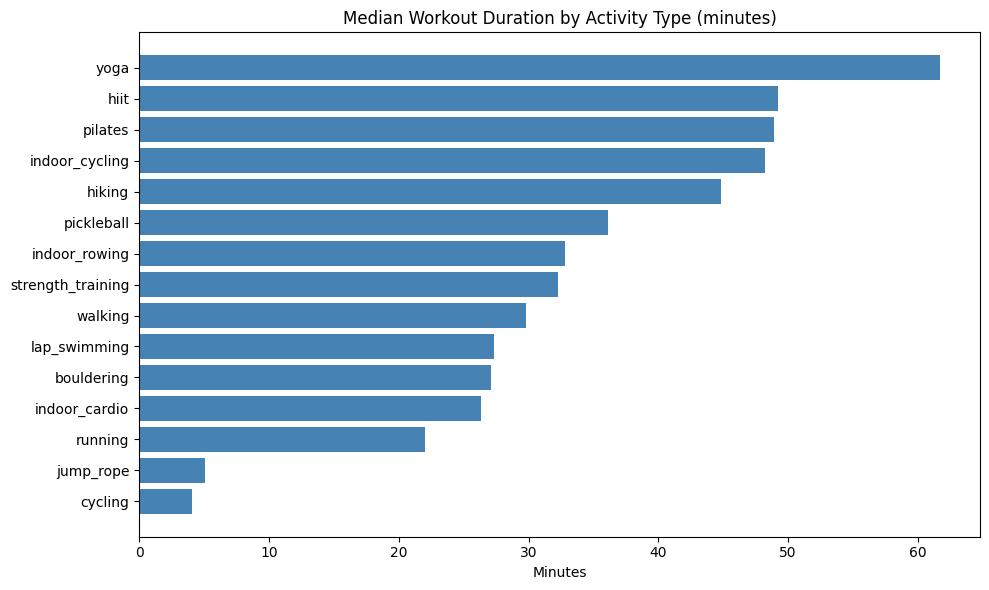

In [6]:
duration_by_type = df_act.groupby('activityType')['duration_minutes'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(duration_by_type.index, duration_by_type.values, color='steelblue')
ax.set_title('Median Workout Duration by Activity Type (minutes)')
ax.set_xlabel('Minutes')
plt.tight_layout()
plt.show()

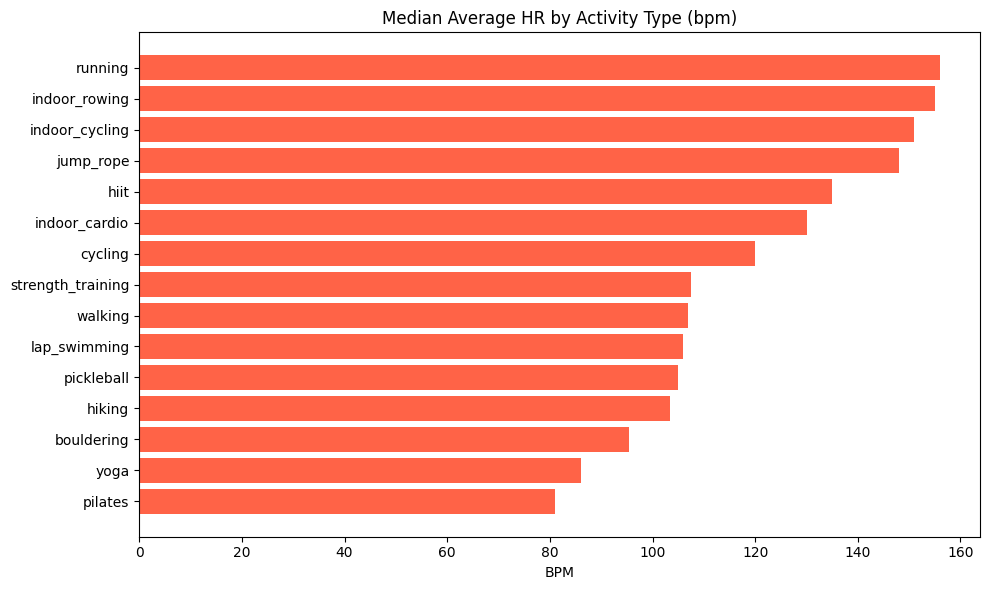

In [7]:
hr_by_type = df_act.groupby('activityType')['avgHr'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(hr_by_type.index, hr_by_type.values, color='tomato')
ax.set_title('Median Average HR by Activity Type (bpm)')
ax.set_xlabel('BPM')
plt.tight_layout()
plt.show()

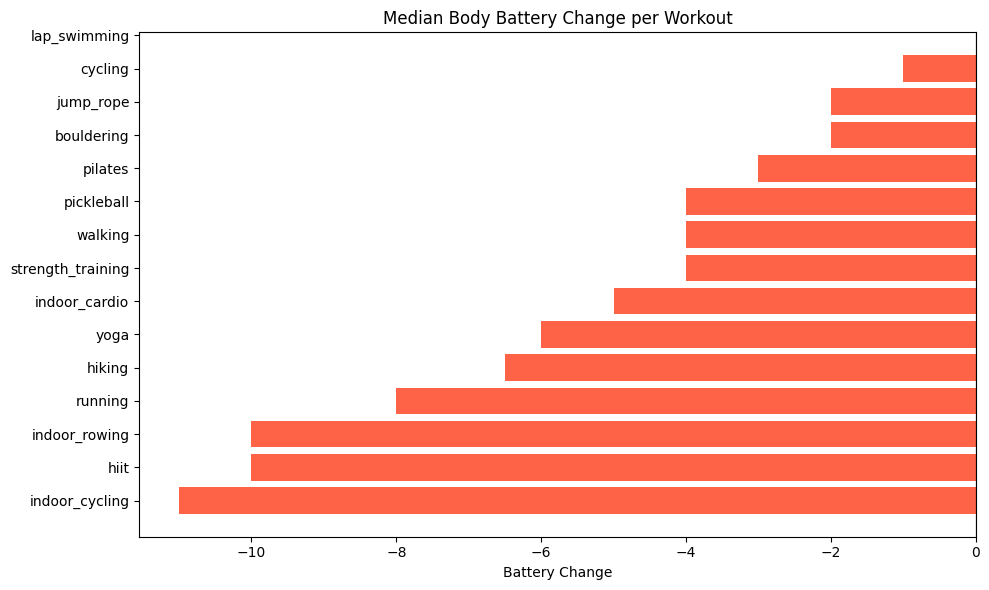

In [8]:
battery_by_type = df_act.groupby('activityType')['differenceBodyBattery'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in battery_by_type.values]
ax.barh(battery_by_type.index, battery_by_type.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Median Body Battery Change per Workout')
ax.set_xlabel('Battery Change')
plt.tight_layout()
plt.show()